In [1]:
import pandas as pd
df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


In [2]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [3]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

In [4]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

In [5]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [6]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [7]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [8]:
df_full = df.merge(df_im, on = "objID", how = 'left')

In [9]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [10]:
import os
os.chdir("/home/mbatt")

In [11]:
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

In [12]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']
dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())

In [13]:
dff = dff.sample(frac=1, random_state=42)

In [14]:
dff.to_csv('/home/mbatt/gravitational_lensing/ready_data.csv')

In [15]:
import pandas as pd
dff = pd.read_csv('/home/mbatt/gravitational_lensing/ready_data.csv', index_col = 0)

In [16]:
import torch

def augment_batch(x, y):
    k = torch.randint(0, 4, (1,)).item()  # 0, 1, 2, 3
    if k > 0:
        x = torch.rot90(x, k, dims=(1, 2))
        RE   = y[0]
        e1   = y[1]
        e2   = y[2]
        g1   = y[3]
        g2   = y[4]

        theta = k * 90
        if theta in [90, 270]:
            e1 = -e1
            e2 = -e2
            g1 = -g1
            g2 = -g2
        y = torch.stack([RE, e1, e2, g1, g2], dim=0)
    return x, y, k

## Load data

In [17]:
import os
os.chdir('/home/mbatt/gravitational_lensing')

In [18]:
!pwd

/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing


In [19]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [20]:
import torch
from torch.utils.data import random_split

path_tensor = "/home/mbatt/data"
full_dataset = LensDataset(dff, path_tensor)

train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

In [21]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.hub import load
dinov2_vitb14 = load("facebookresearch/dinov2", "dinov2_vits14")

device = "cuda" if torch.cuda.is_available() else "cpu"

num_blocks = len(dinov2_vitb14.blocks)

class FinetunedViTB14(nn.Module):
    def __init__(self, dinov2):
        super().__init__()
        
        # 4-band → 3-band adapter
        self.adapter = nn.Conv2d(4, 3, kernel_size=1)

        # Pretrained DINOv2 backbone
        self.backbone = dinov2

        # Freeze backbone initially
        for p in self.backbone.parameters():
            p.requires_grad = True
        
        # Regression head
        self.head = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 5)
        )

    def forward(self, x):
        # x = self.adapter(x)  # enable if needed
        feats = self.backbone(x)  # CLS embedding
        return self.head(feats)

# Instantiate fine‑tuned model
model = FinetunedViTB14(dinov2_vitb14).to(device)

Using cache found in /home/mbatt/.cache/torch/hub/facebookresearch_dinov2_main
WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.5.1+cu121)
    Python  3.10.19 (you have 3.12.4)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
/home/mbatt/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/mbatt/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/mbatt/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Bl

In [22]:
# import torch
# import torch.nn as nn
# import matplotlib.pyplot as plt

# # ============================================================
# # 1. LOAD BASE MODEL (DINOv2 ViT-B/14)
# # ============================================================

# from torch.hub import load
# dinov2_vitb14 = load("facebookresearch/dinov2", "dinov2_vits14")
# dinov2_vitb14.eval()

# device = "cuda" if torch.cuda.is_available() else "cpu"
# dinov2_vitb14.to(device)

# num_blocks = len(dinov2_vitb14.blocks)

# # ============================================================
# # 2. DEFINE YOUR FINETUNED MODEL WRAPPER
# # ============================================================

# class FinetunedViTB14(nn.Module):
#     def __init__(self, dinov2):
#         super().__init__()
        
#         # 4-band → 3-band adapter
#         self.adapter = nn.Conv2d(4, 3, kernel_size=1)

#         # Pretrained DINOv2 backbone
#         self.backbone = dinov2

#         # Freeze backbone initially
#         for p in self.backbone.parameters():
#             p.requires_grad = False
        
#         # Regression head
#         self.head = nn.Sequential(
#             nn.Linear(384, 256),
#             nn.ReLU(),
#             nn.Linear(256, 5)
#         )

#     def forward(self, x):
#         # x = self.adapter(x)  # enable if needed
#         feats = self.backbone(x)  # CLS embedding
#         return self.head(feats)

# # Instantiate fine‑tuned model
# model = FinetunedViTB14(dinov2_vitb14).to(device)
# model.eval()

# def centering(K):
#     n = K.size(0)
#     unit = torch.ones((n, n), device=K.device)
#     I = torch.eye(n, device=K.device)
#     H = I - unit / n
#     return H @ K @ H

# def linear_CKA(X, Y):
#     K = X @ X.T
#     L = Y @ Y.T

#     Kc = centering(K)
#     Lc = centering(L)

#     hsic = (Kc * Lc).sum()
#     norm_x = torch.sqrt((Kc * Kc).sum())
#     norm_y = torch.sqrt((Lc * Lc).sum())

#     return hsic / (norm_x * norm_y + 1e-8)

# base_cls = {i: [] for i in range(num_blocks)}
# ft_cls   = {i: [] for i in range(num_blocks)}

# def make_hook(storage, block_id):
#     def hook(module, input, output):
#         storage[block_id].append(output[:, 0, :].detach().cpu())
#     return hook

# # Base model hooks
# for i, blk in enumerate(dinov2_vitb14.blocks):
#     blk.register_forward_hook(make_hook(base_cls, i))

# # Fine‑tuned model hooks
# for i, blk in enumerate(model.backbone.blocks):
#     blk.register_forward_hook(make_hook(ft_cls, i))

# with torch.no_grad():
#     for xb, _ in val_loader:
#         xb = xb.to(device)
#         xb = xb[:, :-1, :, :]  # remove last band if needed

#         _ = dinov2_vitb14(xb)     # base model
#         _ = model.backbone(xb)    # fine‑tuned backbone

# cka_scores = {}

# for block_id in range(num_blocks):
#     X = torch.cat(base_cls[block_id], dim=0)   # [N, 768]
#     Y = torch.cat(ft_cls[block_id], dim=0)     # [N, 768]

#     score = linear_CKA(X, Y).item()
#     cka_scores[block_id] = score
#     print(f"Block {block_id} → CKA = {score:.4f}")

# plt.plot(
#     list(cka_scores.keys()),
#     list(cka_scores.values()),
#     marker='o',
#     label='CKA similarity'
# )

# plt.xlabel("Transformer Block")
# plt.ylabel("CKA (0–1)")
# plt.title("Representation Similarity: Base vs Fine‑tuned DINOv2")
# plt.grid(True)
# plt.legend()
# plt.show()

In [23]:
# for (n1, p1), (n2, p2) in zip(
#     dinov2_vitb14.named_parameters(),
#     model.backbone.named_parameters()
# ):
#     print(
#         n1,
#         torch.norm(p1 - p2).item()
#     )
#     break

In [24]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 22,156,436
Trainable parameters: 22,156,436


In [25]:
import torch
print(torch.cuda.is_available())


True


In [26]:
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def weighted_mse(pred, target, weights):
    loss = F.mse_loss(pred, target, reduction='none')
    loss = loss * weights
    return loss.mean()           

weights = torch.tensor([1, 1, 1, 1, 1], device=device)

In [27]:
from process_training import Trainer
import warnings
warnings.filterwarnings("ignore")

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.optim.lr_scheduler import ReduceLROnPlateau


patience = 25
early_stop_counter = 0

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


train_losses = []
val_losses = []

best_val_loss = float('inf')
best_weights = None
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)
scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=10, gamma=0.5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100)

best_val_loss = float('inf')
best_weights = None

In [29]:
import torch

def augment_batch(x, y):
    k = torch.randint(0, 4, (1,)).item()  # 0, 1, 2, 3
    if k > 0:
        x = torch.rot90(x, k, dims=(2, 3))
        RE   = y[:, 0]
        e1   = y[:, 1]
        e2   = y[:, 2]
        g1   = y[:, 3]
        g2   = y[:, 4]

        theta = k * 90
        if theta in [90, 270]:
            e1 = -e1
            e2 = -e2
            g1 = -g1
            g2 = -g2
        y = torch.stack([RE, e1, e2, g1, g2], dim=1)
    return x, y

In [31]:
import time 
import copy
start = time.time()
for epoch in range(100):
    # ---- TRAIN ----
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        xb = xb[:,:-1,:,:]
        yb, paths = yb[0].to(device), yb[1]
        xb, yb = augment_batch(xb, yb)
        optimizer.zero_grad() # It resets gradients to zero so they don’t accumulate from previous batches.
        outputs = model(xb)
        loss = weighted_mse(outputs, yb, weights)
        loss.backward() # computes gradients
        optimizer.step() # applies them to the model
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            xb = xb[:,:-1,:,:]
            yb, paths = yb[0].to(device), yb[1]
            outputs = model(xb)
            loss = weighted_mse(outputs, yb, weights)
            val_loss += loss.item()
    val_losses.append(val_loss / len(val_loader))
    scheduler.step()
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict()) 
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")
        # ---- EARLY STOPPING ----
    if early_stop_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

process_time = time.time() - start

Epoch 1: train=0.2612, val=0.1782


In [32]:
import os
os.chdir("/home/mbatt/gravitational_lensing/ViT_weights")

torch.save({
    "model": best_weights,
    "optimizer": optimizer.state_dict(),
    "epoch": epoch,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "process_time": process_time
}, "ViT_dinov2_finetuned.pth")

In [ ]:
print(eeeeeeeeeeeeeeee)

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.chdir("/home/mbatt/gravitational_lensing/ViT_weights")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# optimizer = optim.Adam(model.parameters(), lr=1e-5)

checkpoint = torch.load("ViT_dinov2_finetuned.pth", map_location=device)

model.load_state_dict(checkpoint["model"])
# optimizer.load_state_dict(checkpoint["optimizer"])

start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]

FileNotFoundError: [Errno 2] No such file or directory: 'ViT_dinov2_finetuned.pth'

In [ ]:
checkpoint['process_time']/3600

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/ViT_loss_3.png", dpi=300, bbox_inches="tight")
plt.show()


In [43]:
model.eval()
preds = []
targets = []

criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        
        xb = xb.to(device)
        xb = xb[:,:-1,:,:]
        yb = yb.to(device)

        optimizer.zero_grad()

        # ---- Forward pass ----
        outputs = model(xb)

        preds.append(outputs.cpu())
        targets.append(yb.cpu())

# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)

# compute per-parameter MSE
loss = criterion(preds, targets)   # shape (N, 5)
mse = loss.mean(dim=0)             # shape (5,)

print("Per-parameter MSE:", mse)

# --- Compute R2 per parameter ---
y_true_np = targets.numpy()
y_pred_np = preds.numpy()

r2_scores = []
for i in range(5):
    ss_res = np.sum((y_true_np[:, i] - y_pred_np[:, i])**2)
    ss_tot = np.sum((y_true_np[:, i] - np.mean(y_true_np[:, i]))**2)
    r2 = 1 - ss_res / ss_tot
    r2_scores.append(r2)

print("Per-parameter R2:", r2_scores)


Per-parameter MSE: tensor([0.0208, 0.0512, 0.0468, 0.0329, 0.0060])
Per-parameter R2: [0.7494208812713623, -0.9489802122116089, -0.795249342918396, -2.3875300884246826, 0.23350858688354492]


In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize=(15, 8))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Histogram comparison
    plt.subplot(3, 4, places[i][0])
    plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
    plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7)
    plt.title(f"{param_names[i]}")
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
#     plt.subplot(5, 2, 2*i + 2)

    # Extract the variables
    x = y_true_denorm[:, i]
    y = y_pred_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Predicted values")
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="±1σ"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax1.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume")
    
    ax1.set_xlabel("Real values")
    ax1.legend()
    plt.title(f"Real vs Predicted: {param_names[i]}")
#     plt.grid(True)
#     plt.legend()


plt.tight_layout()
plt.show()


RuntimeError: latex was not able to process the following string:
b'\\xb11\\u03c3'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpbud2za2n 5fadb218a22983c92d196b53a8ff6257.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./5fadb218a22983c92d196b53a8ff6257.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr

Error in callback <function _draw_all_if_interactive at 0x150fbc35d580> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'\\xb11\\u03c3'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp3ydjf2tm 5fadb218a22983c92d196b53a8ff6257.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./5fadb218a22983c92d196b53a8ff6257.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr

RuntimeError: latex was not able to process the following string:
b'\\xb11\\u03c3'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpc3avq694 5fadb218a22983c92d196b53a8ff6257.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./5fadb218a22983c92d196b53a8ff6257.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr

<Figure size 1500x800 with 15 Axes>

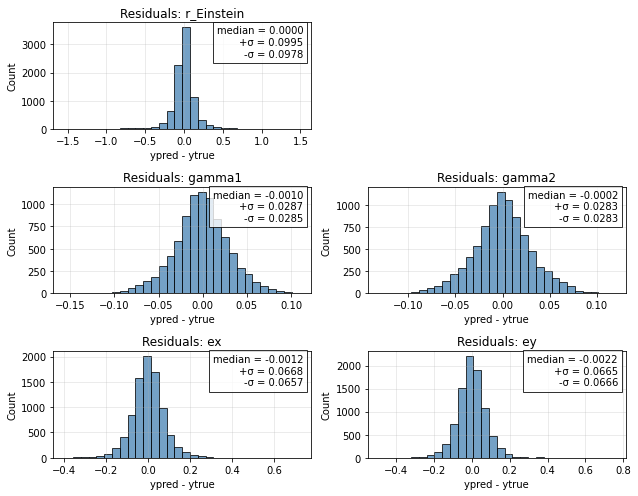

In [71]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Min/max used for normalization ---
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values
scale = df_max - df_min   # range for each parameter

# --- Convert to numpy ---
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * scale + df_min
y_pred_denorm = y_pred * scale + df_min

# --- Compute denormalised errors ---
error_denorm = y_pred_denorm - y_true_denorm

# --- Asymmetric statistics ---
medians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(9, 7))
axes = axes.flatten()  
poss = [1,3,4,5,6]

for i in range(error_denorm.shape[1]):
    plt.subplot(3, 2, poss[i])
    plt.hist(error_denorm[:, i], bins=30, alpha=0.75,
             color="steelblue", edgecolor="black")
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("ypred - ytrue")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # --- Add text box with denormalised stats ---
    text = (
        f"median = {medians[i]:.4f}\n"
        f"+σ = {sigma_plus[i]:.4f}\n"
        f"-σ = {sigma_minus[i]:.4f}"
    )

    plt.text(
        0.97, 0.97, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )

plt.tight_layout()
axes[1].axis("off")
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_residus_sqrt_images_first.png", dpi=300, bbox_inches="tight")
plt.show()